# Hierarchical Parameter Recovery Analysis

Analyzes SMC output from `scripts/parameter_recovery_hierarchical.py`.

In [39]:
import arviz.preview as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from xarray import open_datatree

jax.config.update("jax_enable_x64", True)

## RDM

In [40]:
RESULTS_PATH = "../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/hierarchical_recovery_pop0_approx.nc"
dt = open_datatree(RESULTS_PATH)
dt.groups, dt.param_names

(('/',
  '/posterior',
  '/sample_stats',
  '/observed_data',
  '/constant_data',
  '/prior'),
 ['v_intercept', 'v_slope', 's_true', 'b', 't0'])

### Parameter Summary

In [41]:
summary = az.summary(dt)
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[v_intercept],1.65,0.11,1.49,1.82,2627.59,3482.72,1.0,0.0,0.0
mu[v_slope],2.20,0.14,1.97,2.42,3594.69,3270.45,1.0,0.0,0.0
mu[s_true],1.07,0.04,1.00,1.13,3653.90,3746.94,1.0,0.0,0.0
mu[b],1.04,0.08,0.91,1.18,2966.77,3584.72,1.0,0.0,0.0
mu[t0],0.34,0.01,0.33,0.36,2630.60,2991.83,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
t0[15],0.38,0.02,0.35,0.41,3550.82,3253.39,1.0,0.0,0.0
t0[16],0.35,0.01,0.32,0.37,3489.51,3524.28,1.0,0.0,0.0
t0[17],0.38,0.02,0.34,0.41,3364.80,3564.12,1.0,0.0,0.0
t0[18],0.31,0.01,0.30,0.32,3151.57,3557.08,1.0,0.0,0.0


### Convergence Diagnostics

In [42]:
(summary["r_hat"] > 1.01).sum()

np.int64(0)

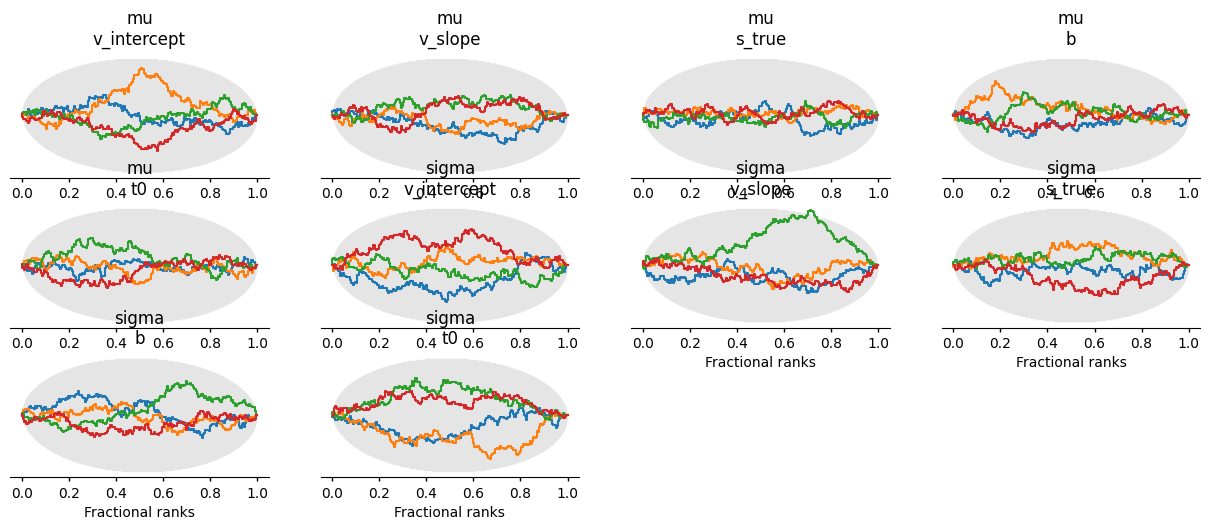

In [43]:
fig = az.plot_rank(dt, var_names=["mu", "sigma"]);

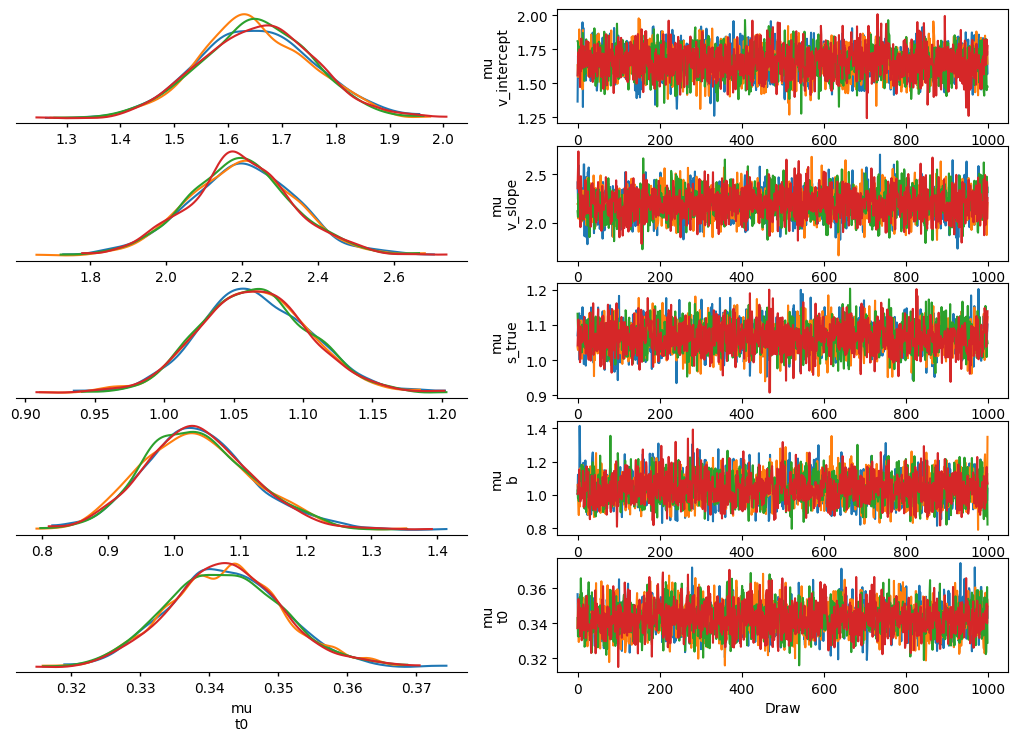

In [44]:
fig = az.plot_trace_dist(dt, var_names=["mu"], compact=False);

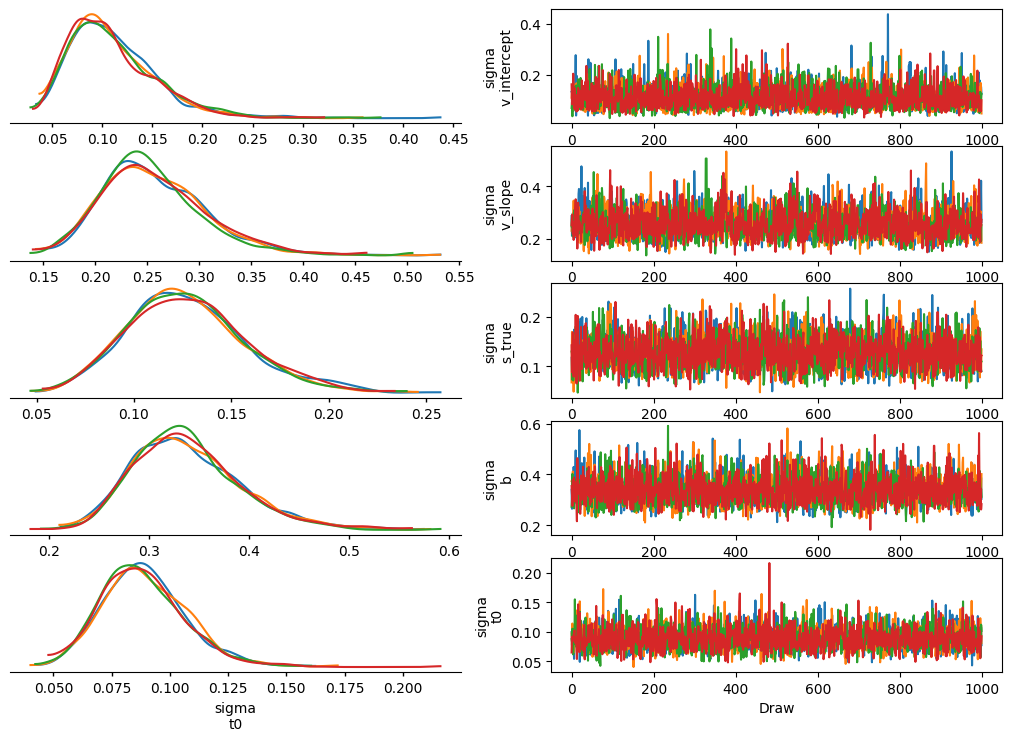

In [45]:
fig = az.plot_trace_dist(dt, var_names=["sigma"], compact=False);

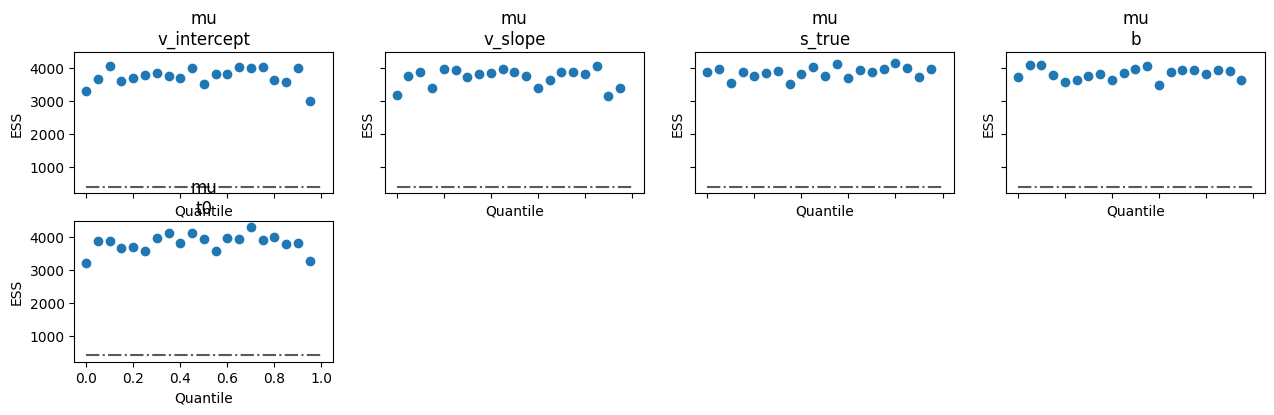

In [46]:
az.plot_ess(dt, var_names=["mu"]);

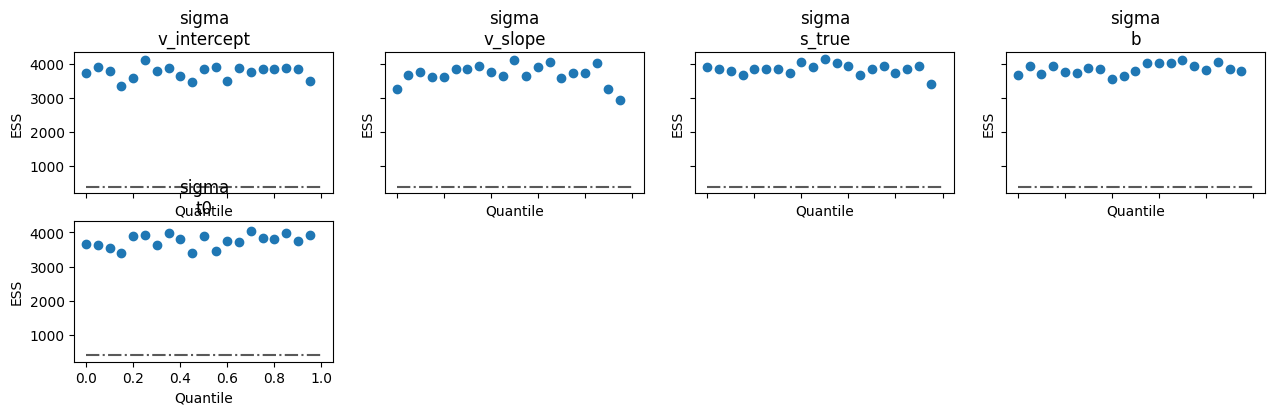

In [47]:
az.plot_ess(dt, var_names=["sigma"]);

### Posterior Distributions

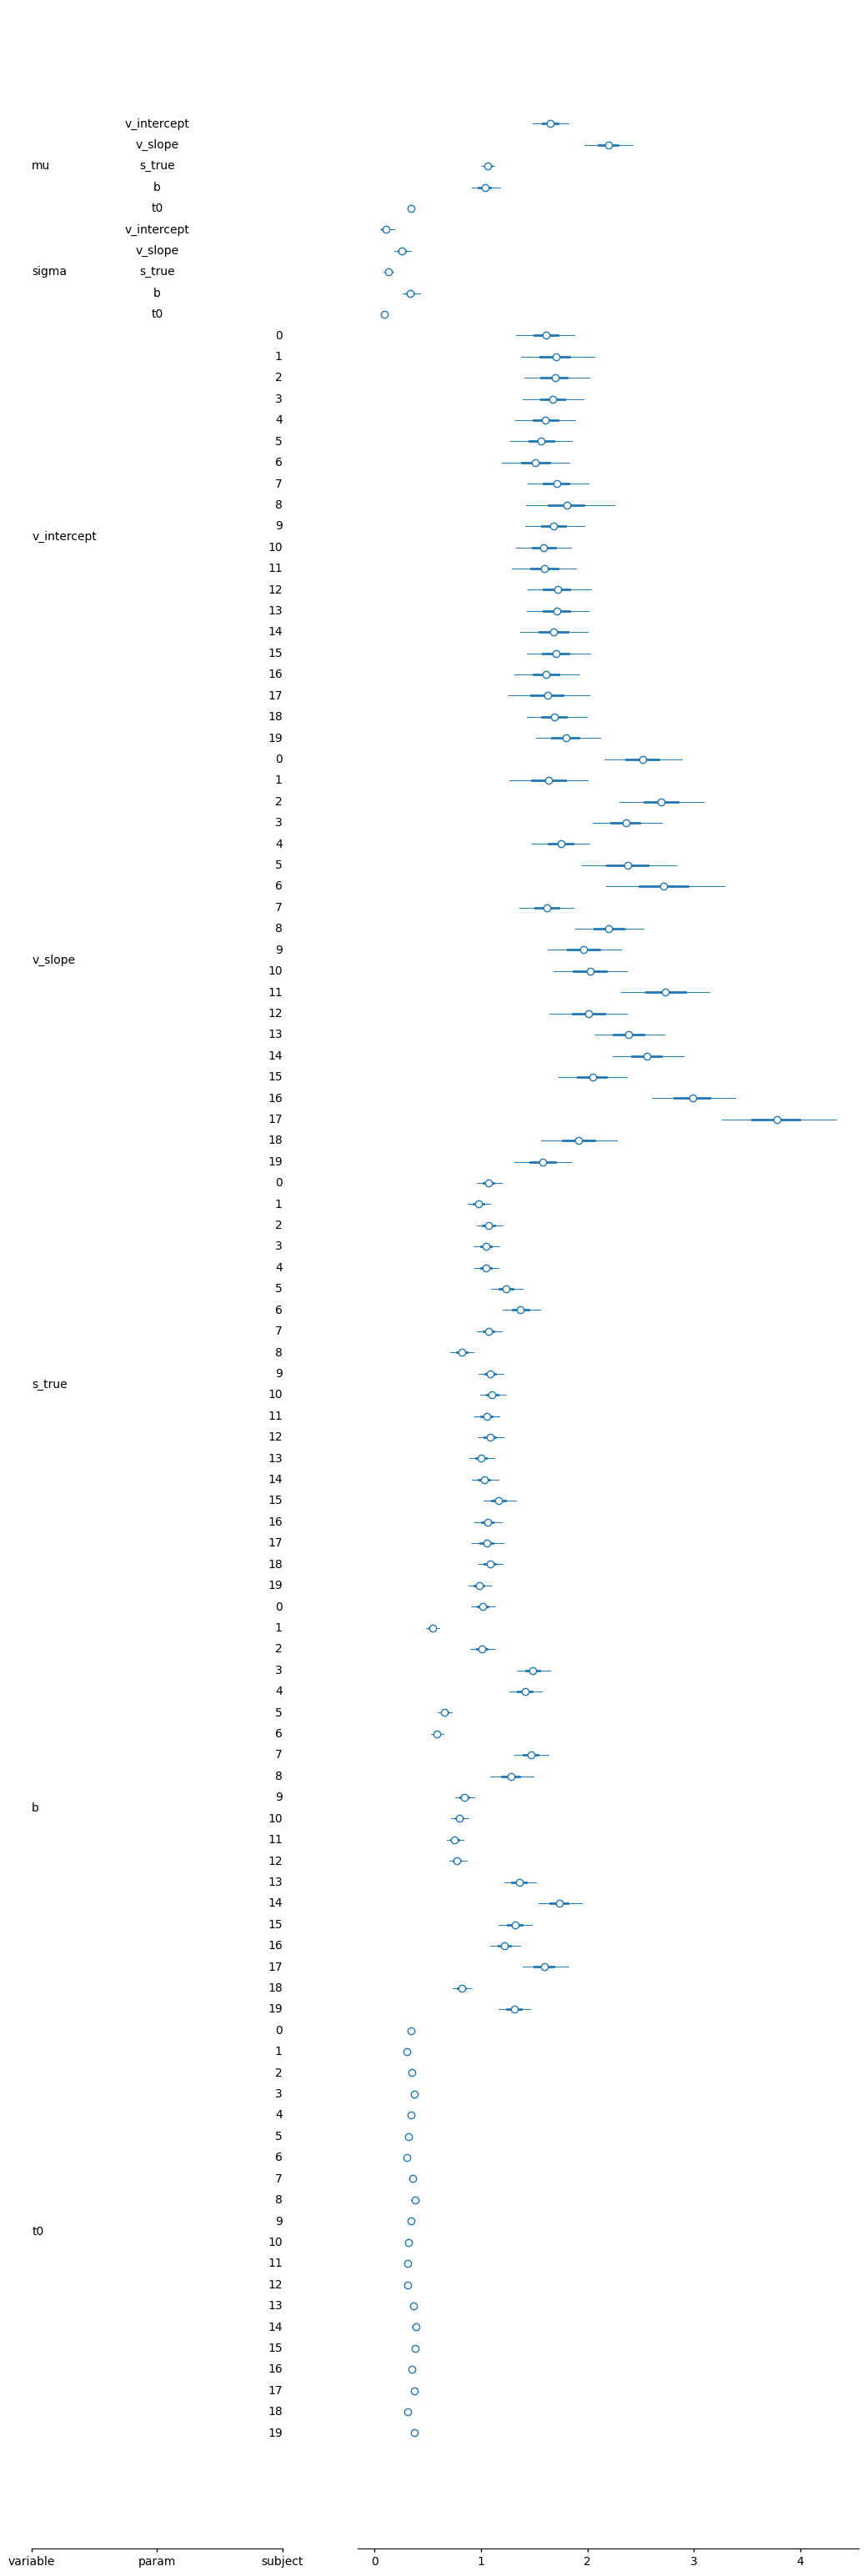

In [48]:
az.plot_forest(dt, combined=True);

### Parameter Recovery

In [49]:
def plot_parameter_recovery(dt):
    param_names = dt.param_names

    fig, axarr = plt.subplots(1, len(param_names), figsize=(3 * len(param_names), 3))

    for ax, var in zip(axarr, param_names):
        posterior_mean = dt.posterior[var].mean(dim=["chain", "draw"]).values
        posterior_sd = dt.posterior[var].std(dim=["chain", "draw"]).values
        true_value = dt.constant_data.theta.sel(param=var)
        ax.errorbar(true_value, posterior_mean, yerr=posterior_sd, fmt='o', alpha=0.7, capsize=3)
        lims = [min(true_value.min(), posterior_mean.min()), max(true_value.max(), posterior_mean.max())]
        ax.plot(lims, lims, 'k--', lw=1)
        r, _ = stats.pearsonr(true_value, posterior_mean)
        ax.set(title=f"{var} - r = {r:.2f}", xlabel="True", ylabel="Posterior mean ± SD")

    plt.tight_layout()

    return fig, axarr

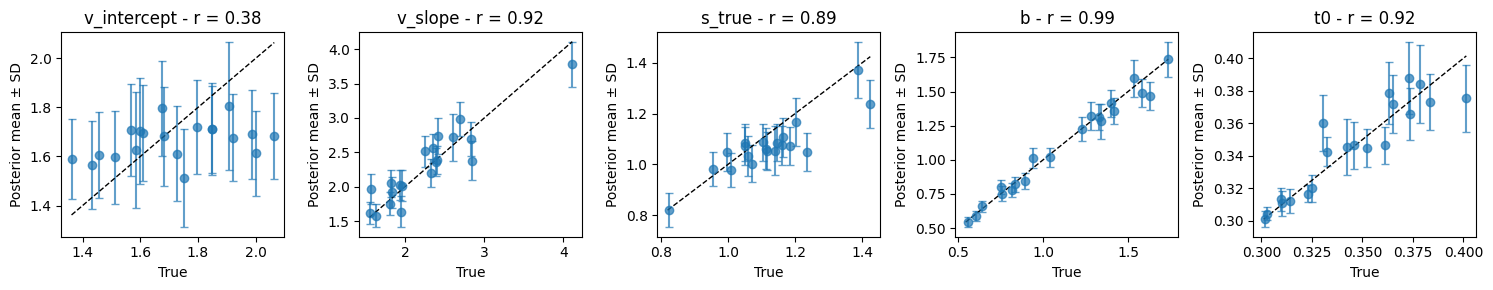

In [50]:
plot_parameter_recovery(dt);

### Posterior Contraction

In [51]:
def calc_posterior_contraction(dt, param_name):
    posterior_var = dt.posterior[param_name].var(dim=["chain", "draw"]).values
    prior_var = dt.prior[param_name].var(dim=["draw"]).values
    return np.clip(1.0 - (posterior_var / prior_var), 0, 1)

In [52]:
def plot_posterior_contraction(dt):
    param_names = dt.param_names

    fig, axarr = plt.subplots(1, len(param_names), figsize=(3 * len(param_names), 3))

    for ax, var in zip(axarr, param_names):
        posterior_contraction = calc_posterior_contraction(dt, var)
        true_value = dt.constant_data.theta.sel(param=var)
        ax.plot(true_value, posterior_contraction, "o")
        ax.ticklabel_format(useOffset=False)
        ax.set(title=var, xlabel="True parameter value", ylabel="Posterior contraction")

    plt.tight_layout()

    return fig, axarr

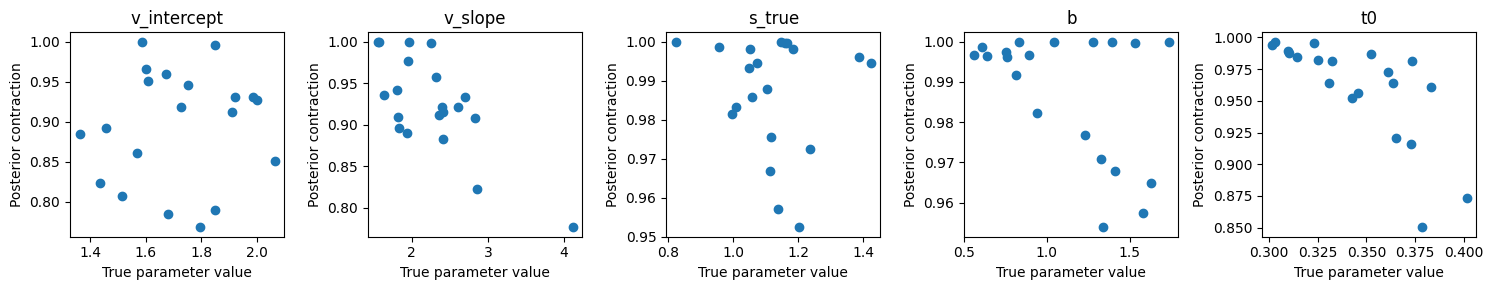

In [53]:
plot_posterior_contraction(dt);

### Prior Samples

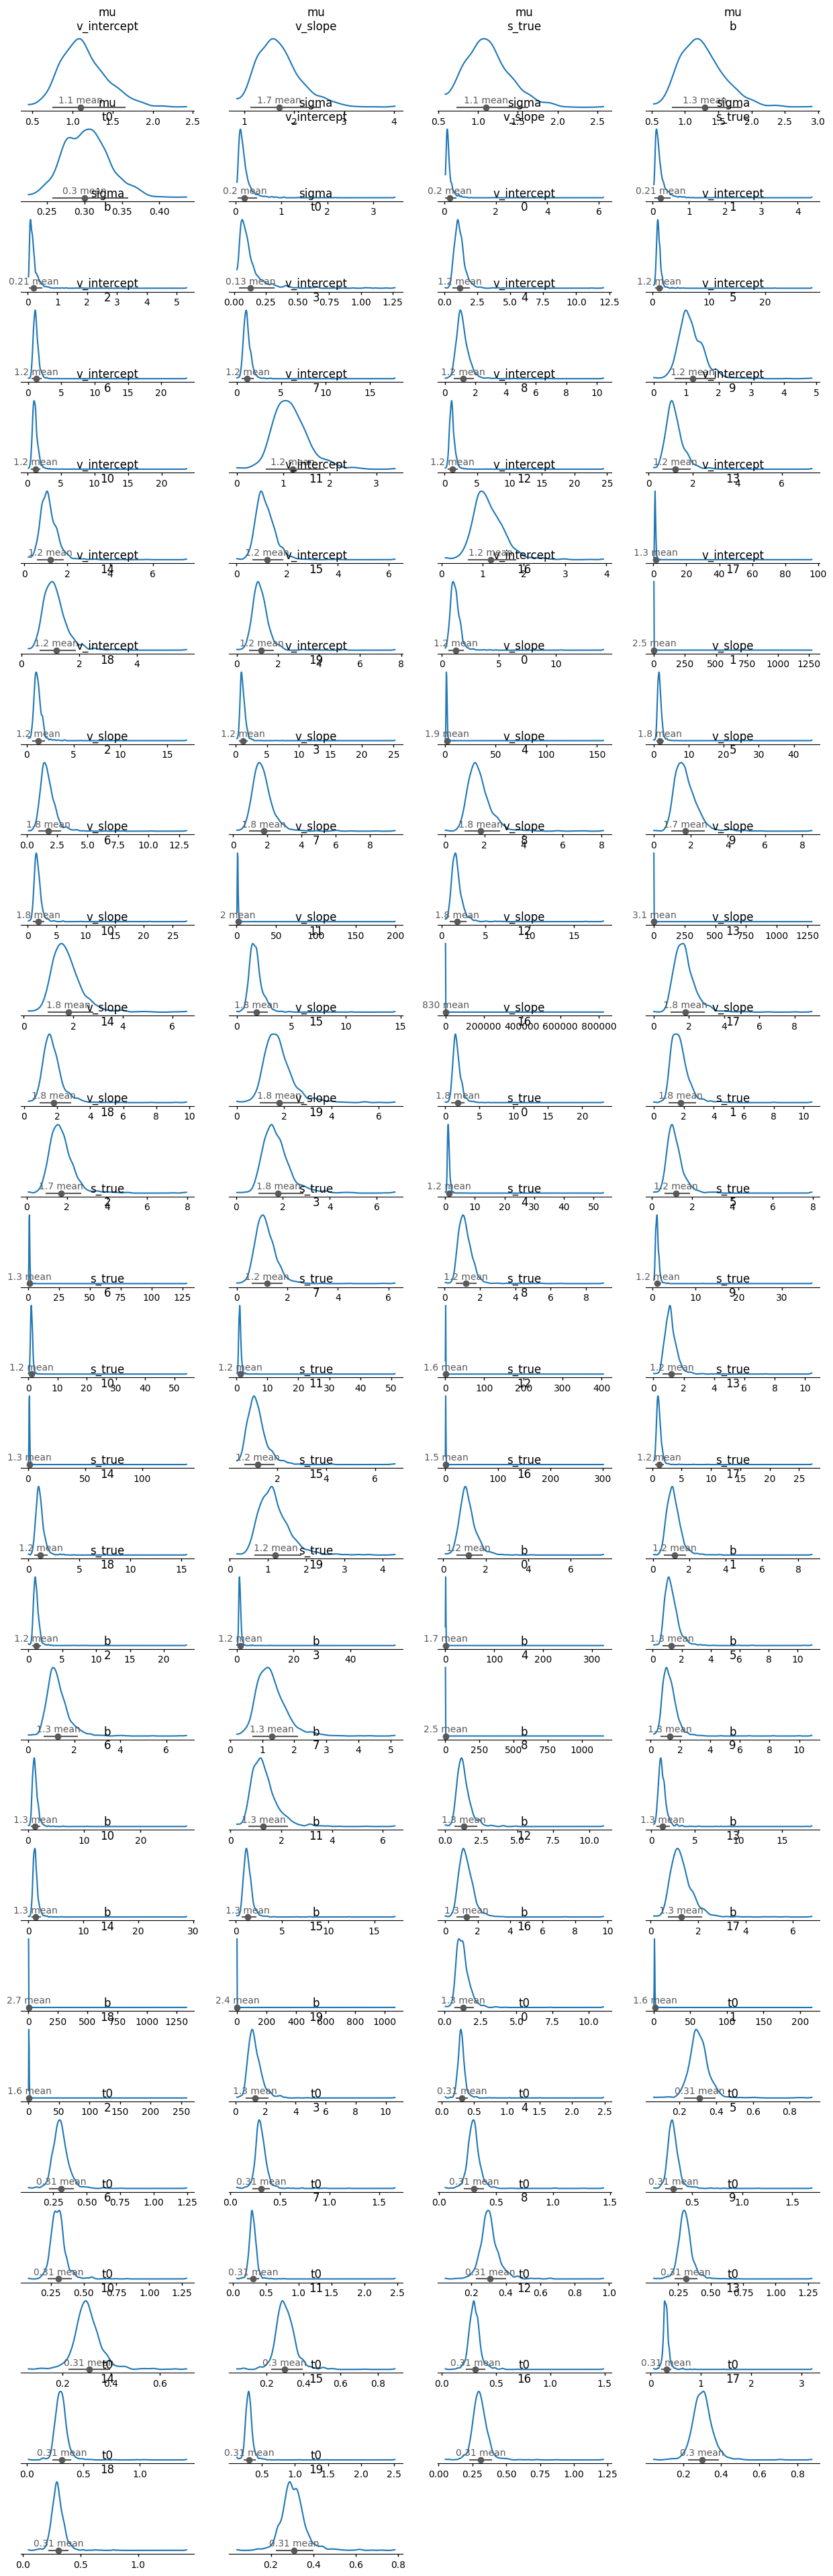

In [54]:
az.plot_dist(dt, group="prior");

### Data

In [55]:
def plot_data_hist(dt):
    subject_idx = dt.observed_data.subject.values
    num_subjects = len(subject_idx)
    fig, axarr = plt.subplots(2, num_subjects // 2, figsize=(2 * num_subjects, 6))
    if num_subjects == 1:
        axarr = [axarr]

    for posterior_sd in range(num_subjects):
        ax = axarr.flatten()[posterior_sd]
        rt = dt.observed_data.rt[posterior_sd]
        choice = dt.observed_data.choice[posterior_sd]
        ax.hist(rt[choice == 1], bins=20, color="darkgreen", alpha=0.5, label="correct")
        ax.hist(rt[choice == 0], bins=20, color="indianred", alpha=0.5, label="error")
        ax.set_title(f"Subject {posterior_sd}; Acc = {float(np.round(np.mean(choice), 2))}")
        ax.set_xlabel("RT")
        if posterior_sd == 0:
            ax.legend()

    fig.tight_layout()

    return fig, axarr

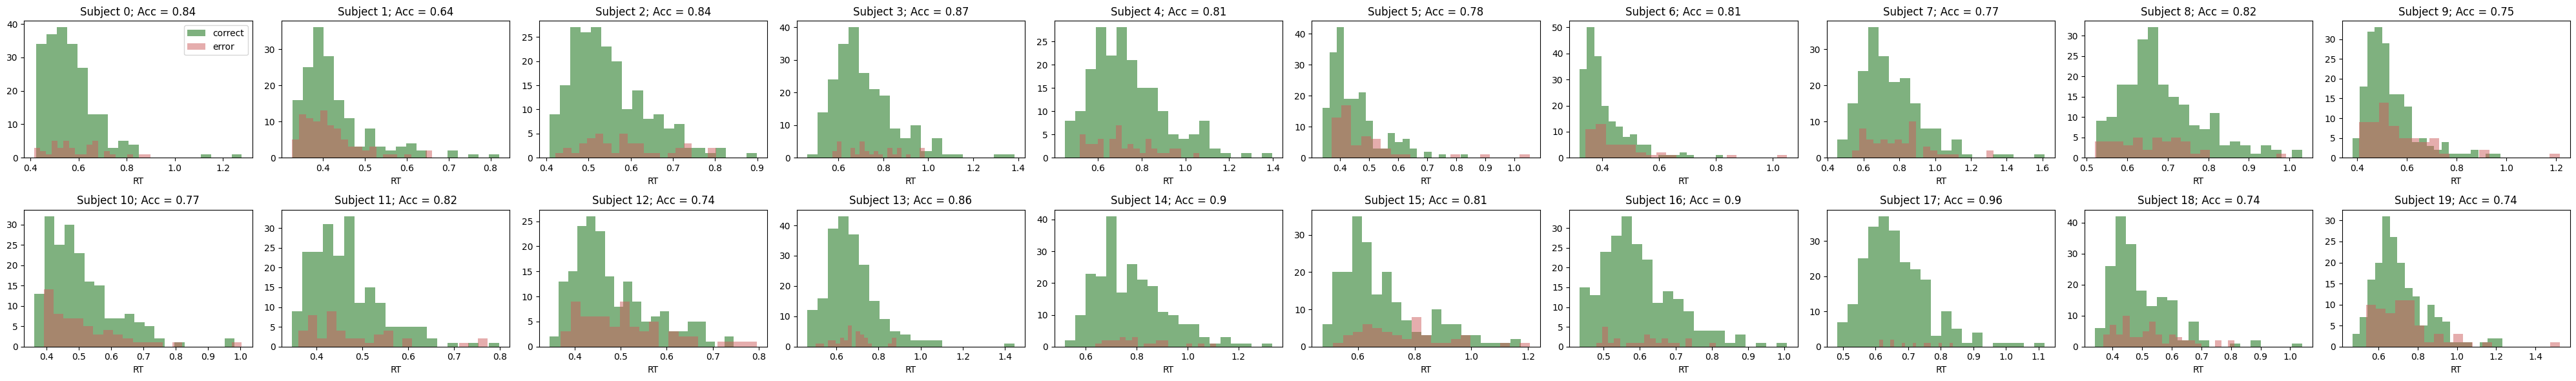

In [56]:
plot_data_hist(dt);

## Neural vs. Analytical

In [57]:
RESULTS_PATH = "../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/hierarchical_recovery_pop0_ref.nc"
dt_ref = open_datatree(RESULTS_PATH)

In [58]:
def plot_parameter_cross_recovery(dt, dt_ref):
    assert np.all(dt.param_names == dt_ref.param_names)

    param_names = dt.param_names

    fig, axarr = plt.subplots(1, len(param_names), figsize=(3 * len(param_names), 3))

    for ax, var in zip(axarr, param_names):
        posterior_mean = dt.posterior[var].mean(dim=["chain", "draw"]).values
        posterior_sd = dt.posterior[var].std(dim=["chain", "draw"]).values
        posterior_mean_ref = dt_ref.posterior[var].mean(dim=["chain", "draw"]).values
        posterior_sd_ref = dt_ref.posterior[var].std(dim=["chain", "draw"]).values
        ax.errorbar(posterior_mean_ref, posterior_mean, xerr=posterior_sd_ref, yerr=posterior_sd, fmt='o', alpha=0.7, capsize=3)
        lims = [min(posterior_mean_ref.min(), posterior_mean.min()), max(posterior_mean_ref.max(), posterior_mean.max())]
        ax.plot(lims, lims, 'k--', lw=1)
        r, _ = stats.pearsonr(posterior_mean_ref, posterior_mean)
        ax.set(title=f"{var} - r = {r:.2f}", xlabel="Posterior mean ± SD (reference)", ylabel="Posterior mean ± SD")

    plt.tight_layout()

    return fig, axarr

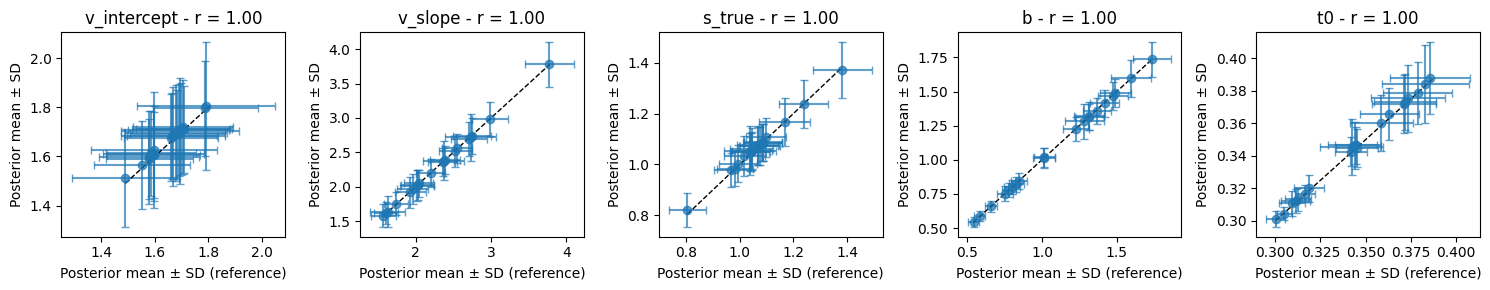

In [59]:
plot_parameter_cross_recovery(dt, dt_ref);

## CRDM

In [60]:
RESULTS_PATH = "../outputs/crdm/model.num_bins=12/model.num_mid=128/model.sampler.dt=0.0005/optimizer=adam_cosine_decay/train_steps=1000000/hierarchical_recovery_pop0_approx.nc"
dt = open_datatree(RESULTS_PATH)
dt.groups, dt.param_names

(('/',
  '/posterior',
  '/sample_stats',
  '/observed_data',
  '/constant_data',
  '/prior'),
 ['v_c_intercept', 'v_c_slope', 'amp', 'tau', 's_true', 'b', 't0'])

### Parameter Summary

In [61]:
summary = az.summary(dt)
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[v_c_intercept],1.70,0.11,1.52,1.87,3693.15,3728.47,1.0,0.0,0.0
mu[v_c_slope],2.03,0.17,1.76,2.30,3236.75,3357.34,1.0,0.0,0.0
mu[amp],0.26,0.02,0.22,0.29,3756.34,3412.78,1.0,0.0,0.0
mu[tau],0.10,0.01,0.09,0.12,3599.74,3825.15,1.0,0.0,0.0
mu[s_true],1.27,0.07,1.16,1.37,3664.81,3760.39,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
t0[15],0.36,0.01,0.34,0.37,3653.71,3032.14,1.0,0.0,0.0
t0[16],0.23,0.01,0.22,0.24,3495.78,3475.96,1.0,0.0,0.0
t0[17],0.38,0.01,0.37,0.39,3392.80,3166.92,1.0,0.0,0.0
t0[18],0.21,0.01,0.20,0.22,3534.45,3419.26,1.0,0.0,0.0


### Convergence Diagnostics

In [62]:
(summary["r_hat"] > 1.01).sum()

np.int64(0)

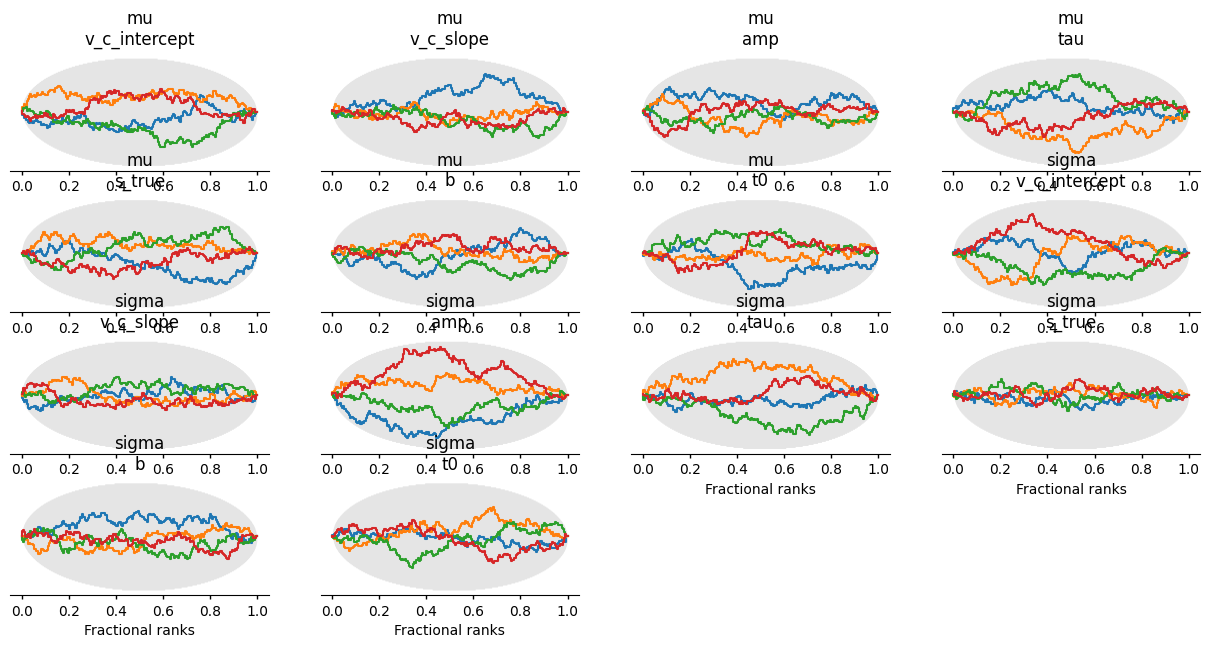

In [63]:
fig = az.plot_rank(dt, var_names=["mu", "sigma"]);

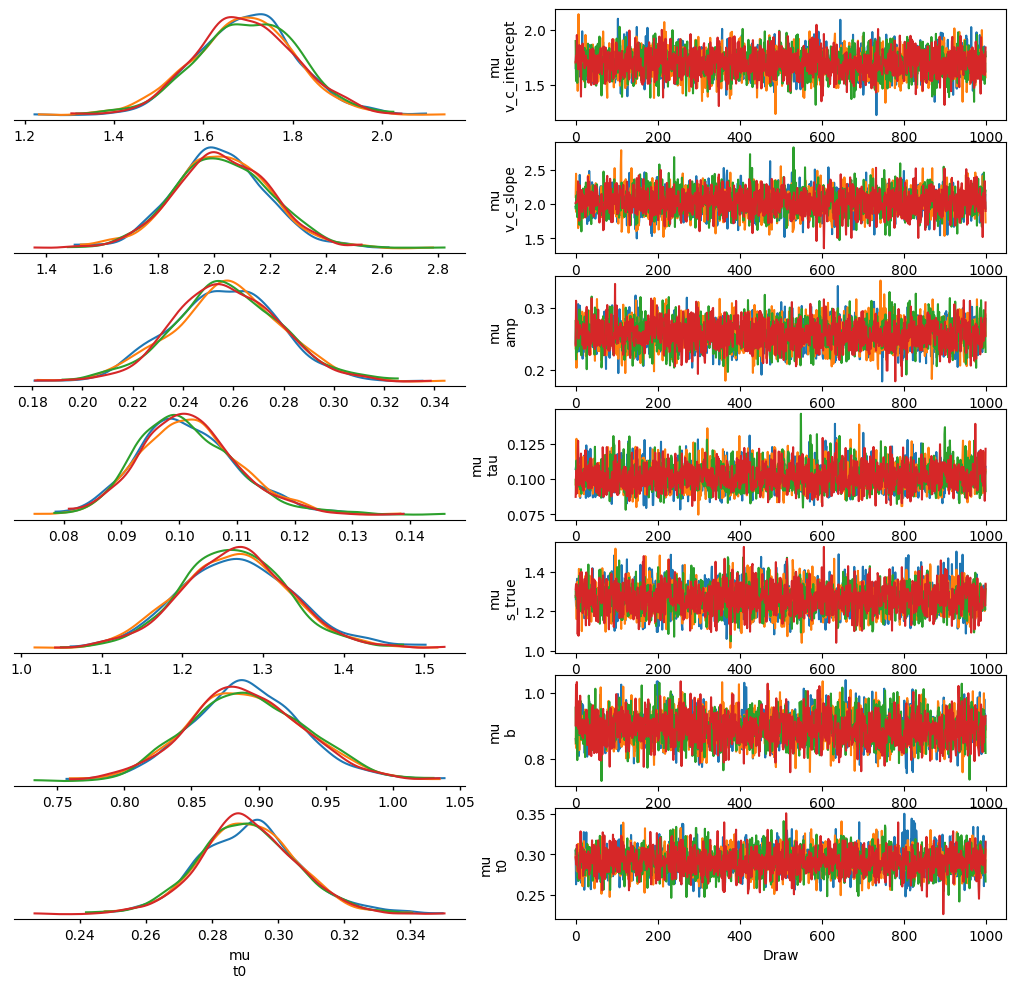

In [64]:
fig = az.plot_trace_dist(dt, var_names=["mu"], compact=False);

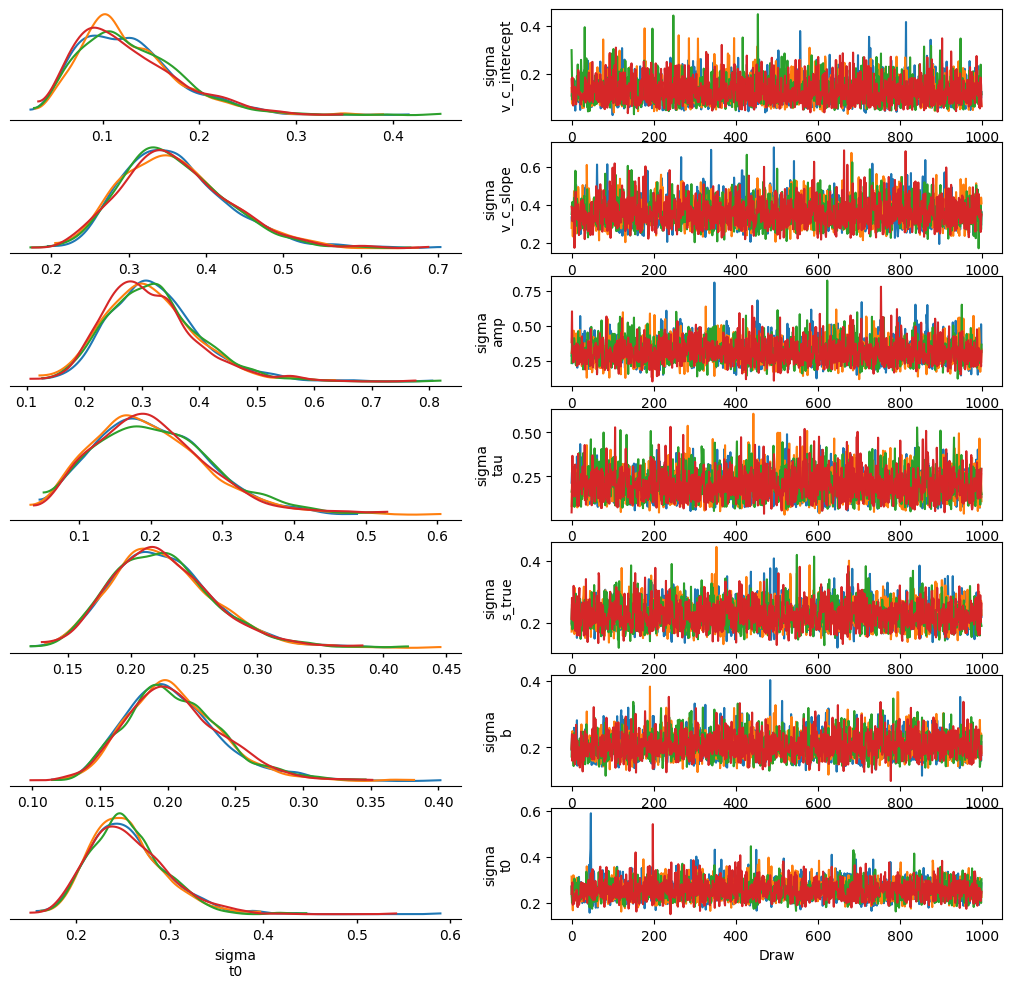

In [65]:
fig = az.plot_trace_dist(dt, var_names=["sigma"], compact=False);

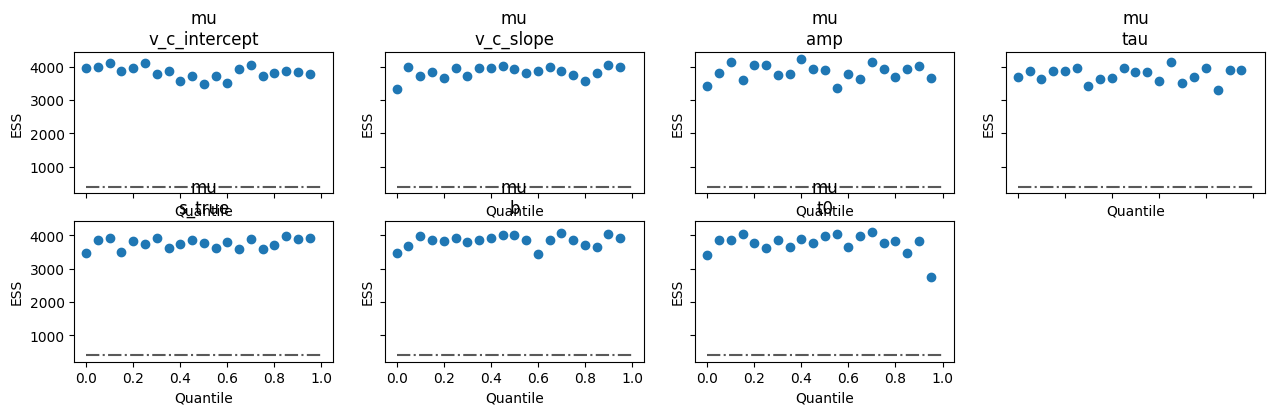

In [66]:
az.plot_ess(dt, var_names=["mu"]);

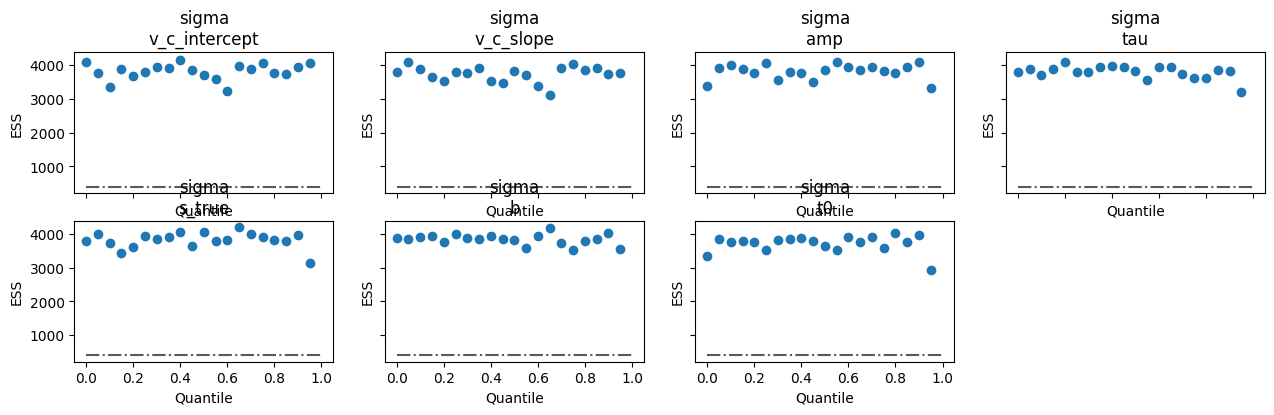

In [67]:
az.plot_ess(dt, var_names=["sigma"]);

### Posterior Distributions

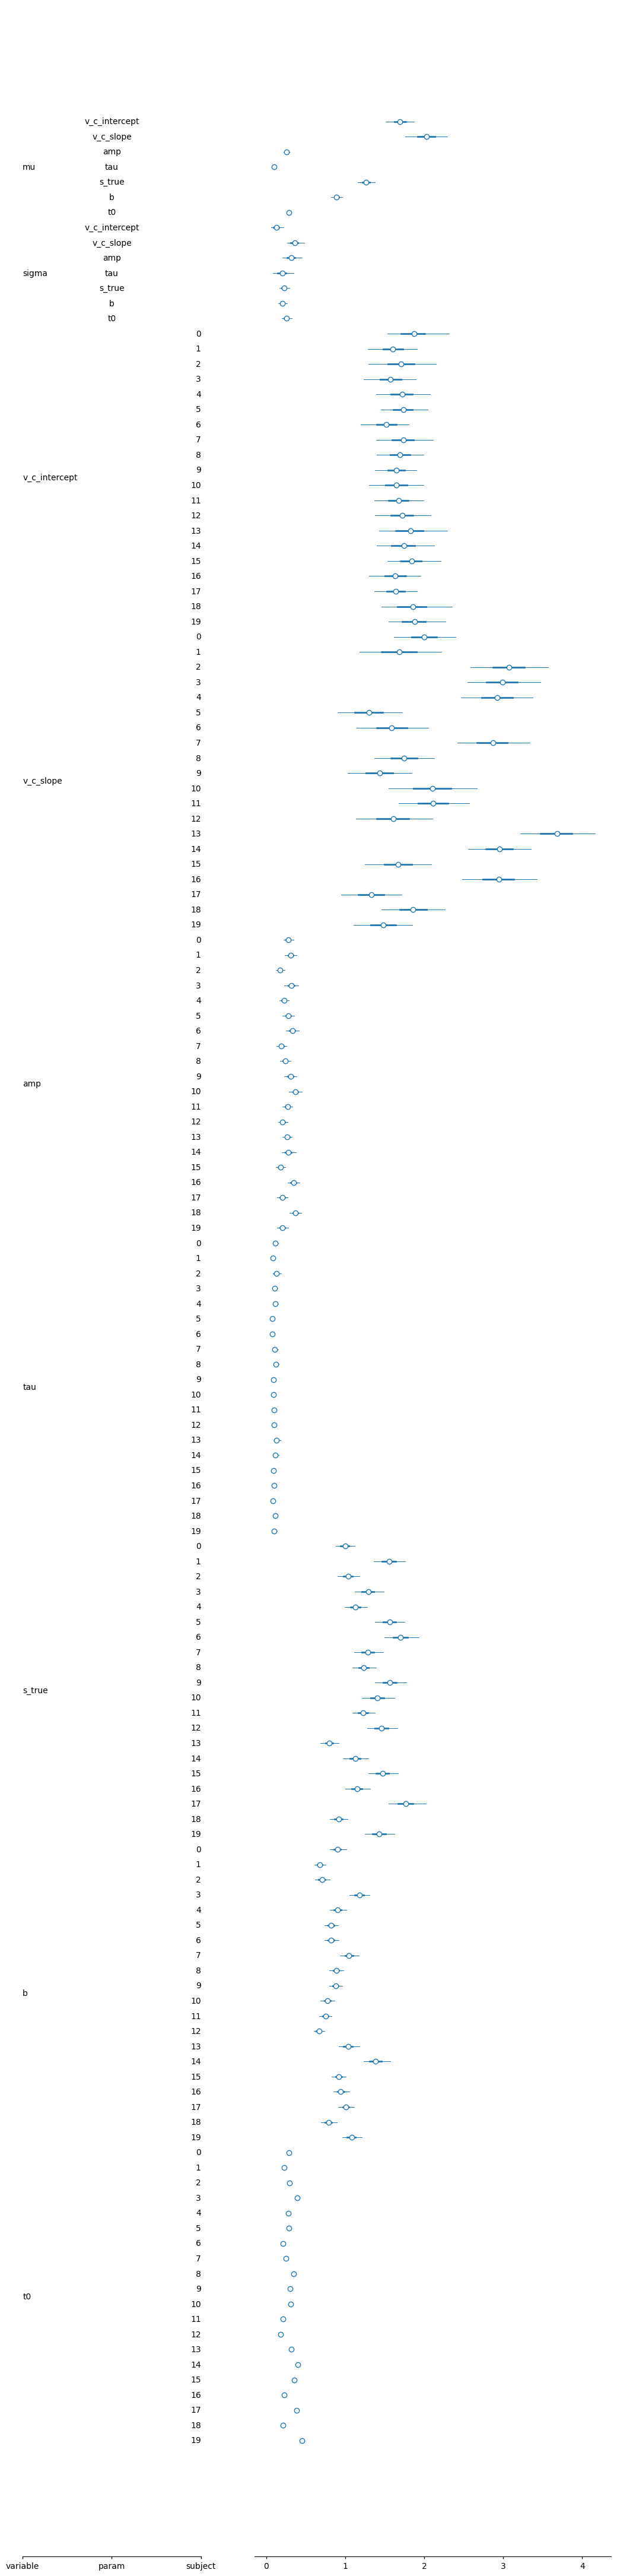

In [68]:
az.plot_forest(dt, combined=True);

### Parameter Recovery

In [69]:
def plot_parameter_recovery(dt):
    param_names = dt.param_names

    fig, axarr = plt.subplots(1, len(param_names), figsize=(3 * len(param_names), 3))

    for ax, var in zip(axarr, param_names):
        posterior_mean = dt.posterior[var].mean(dim=["chain", "draw"]).values
        posterior_sd = dt.posterior[var].std(dim=["chain", "draw"]).values
        true_value = dt.constant_data.theta.sel(param=var)
        ax.errorbar(true_value, posterior_mean, yerr=posterior_sd, fmt='o', alpha=0.7, capsize=3)
        lims = [min(true_value.min(), posterior_mean.min()), max(true_value.max(), posterior_mean.max())]
        ax.plot(lims, lims, 'k--', lw=1)
        r, _ = stats.pearsonr(true_value, posterior_mean)
        ax.set(title=f"{var} - r = {r:.2f}", xlabel="True", ylabel="Posterior mean ± SD")

    plt.tight_layout()

    return fig, axarr

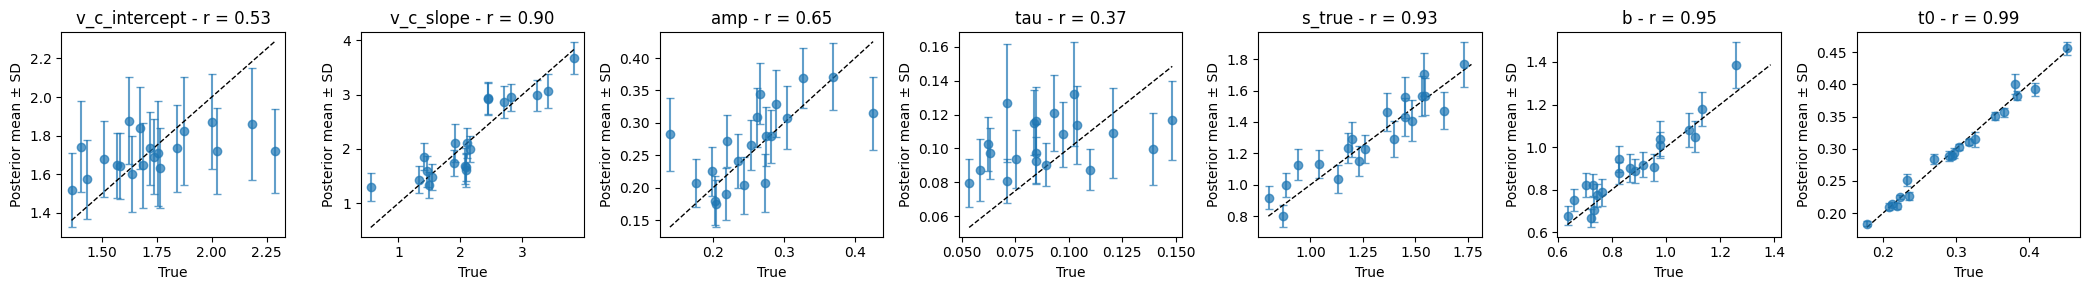

In [70]:
plot_parameter_recovery(dt);

### Posterior Contraction

In [71]:
def calc_posterior_contraction(dt, param_name):
    posterior_var = dt.posterior[param_name].var(dim=["chain", "draw"]).values
    prior_var = dt.prior[param_name].var(dim=["draw"]).values
    return np.clip(1.0 - (posterior_var / prior_var), 0, 1)

In [72]:
def plot_posterior_contraction(dt):
    param_names = dt.param_names

    fig, axarr = plt.subplots(1, len(param_names), figsize=(3 * len(param_names), 3))

    for ax, var in zip(axarr, param_names):
        posterior_contraction = calc_posterior_contraction(dt, var)
        true_value = dt.constant_data.theta.sel(param=var)
        ax.plot(true_value, posterior_contraction, "o")
        ax.ticklabel_format(useOffset=False)
        ax.set(title=var, xlabel="True parameter value", ylabel="Posterior contraction")

    plt.tight_layout()

    return fig, axarr

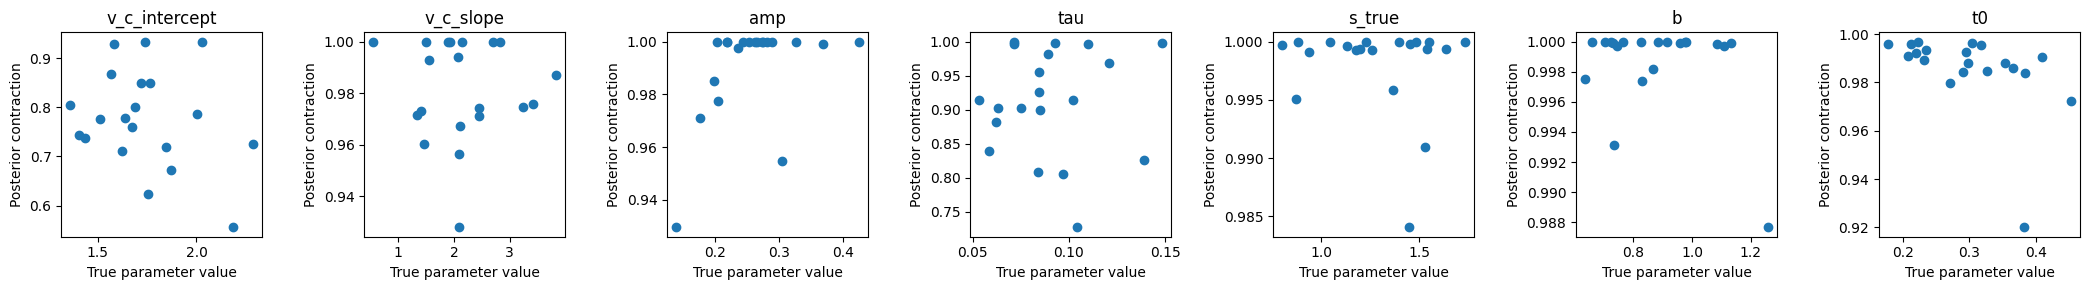

In [73]:
plot_posterior_contraction(dt);

### Prior Samples

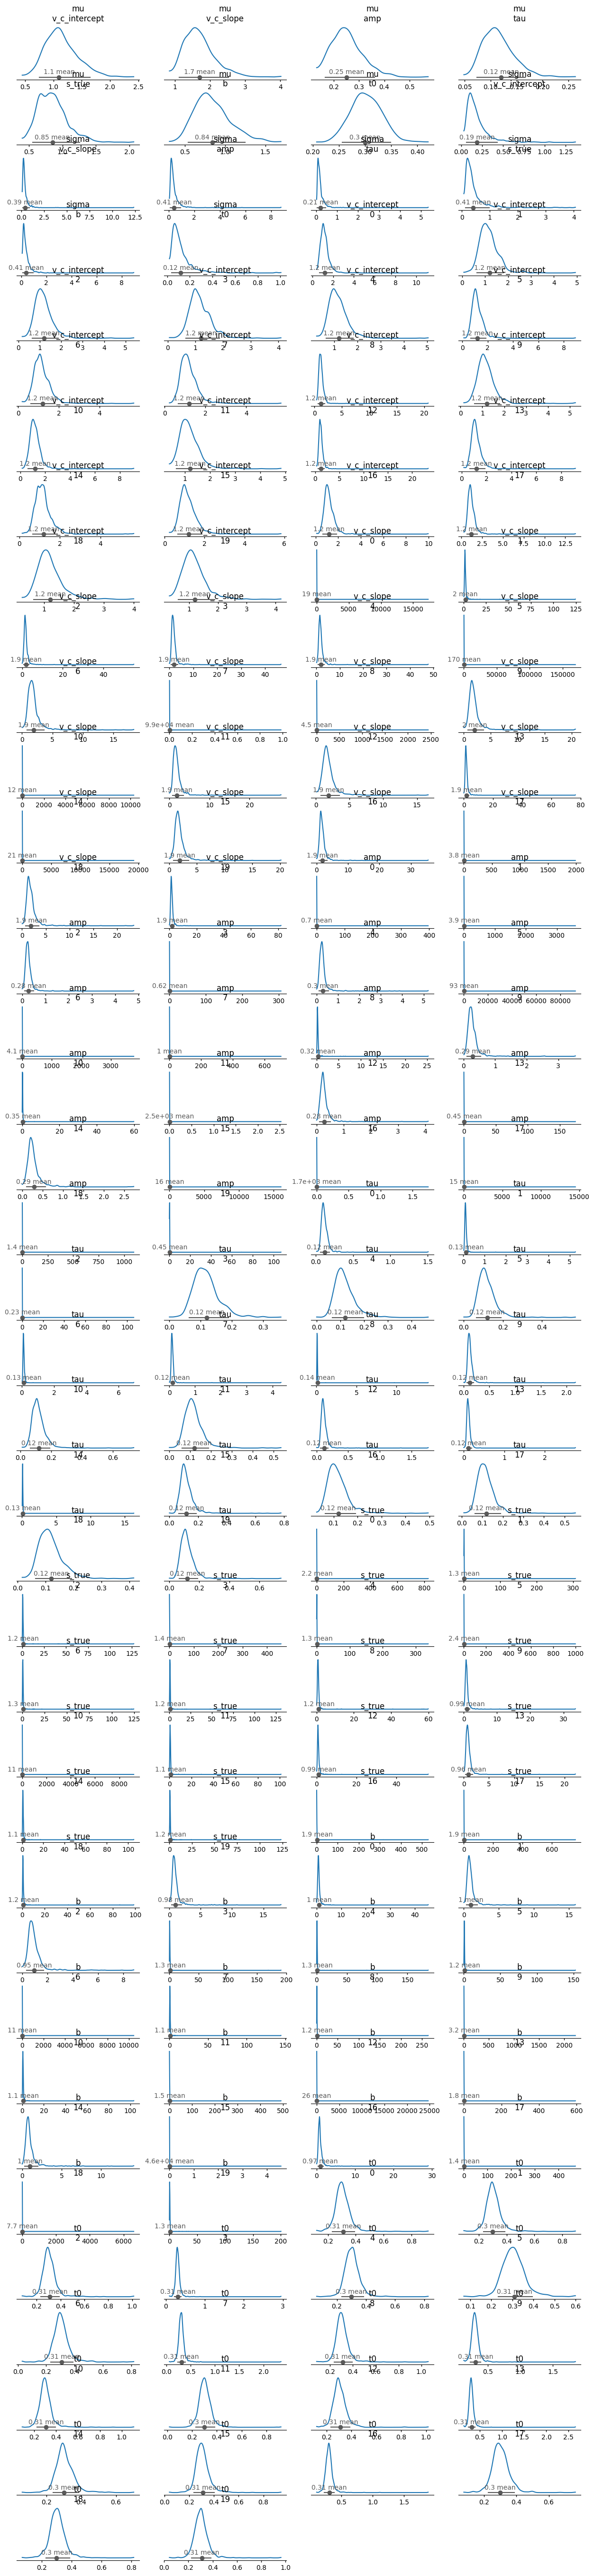

In [74]:
az.plot_dist(dt, group="prior");

### Data

In [75]:
def plot_data_hist(dt):
    subject_idx = dt.observed_data.subject.values
    num_subjects = len(subject_idx)
    fig, axarr = plt.subplots(2, num_subjects // 2, figsize=(2 * num_subjects, 6))
    if num_subjects == 1:
        axarr = [axarr]

    for posterior_sd in range(num_subjects):
        ax = axarr.flatten()[posterior_sd]
        rt = dt.observed_data.rt[posterior_sd]
        choice = dt.observed_data.choice[posterior_sd]
        ax.hist(rt[choice == 1], bins=20, color="darkgreen", alpha=0.5, label="correct")
        ax.hist(rt[choice == 0], bins=20, color="indianred", alpha=0.5, label="error")
        ax.set_title(f"Subject {posterior_sd}; Acc = {float(np.round(np.mean(choice), 2))}")
        ax.set_xlabel("RT")
        if posterior_sd == 0:
            ax.legend()

    fig.tight_layout()

    return fig, axarr

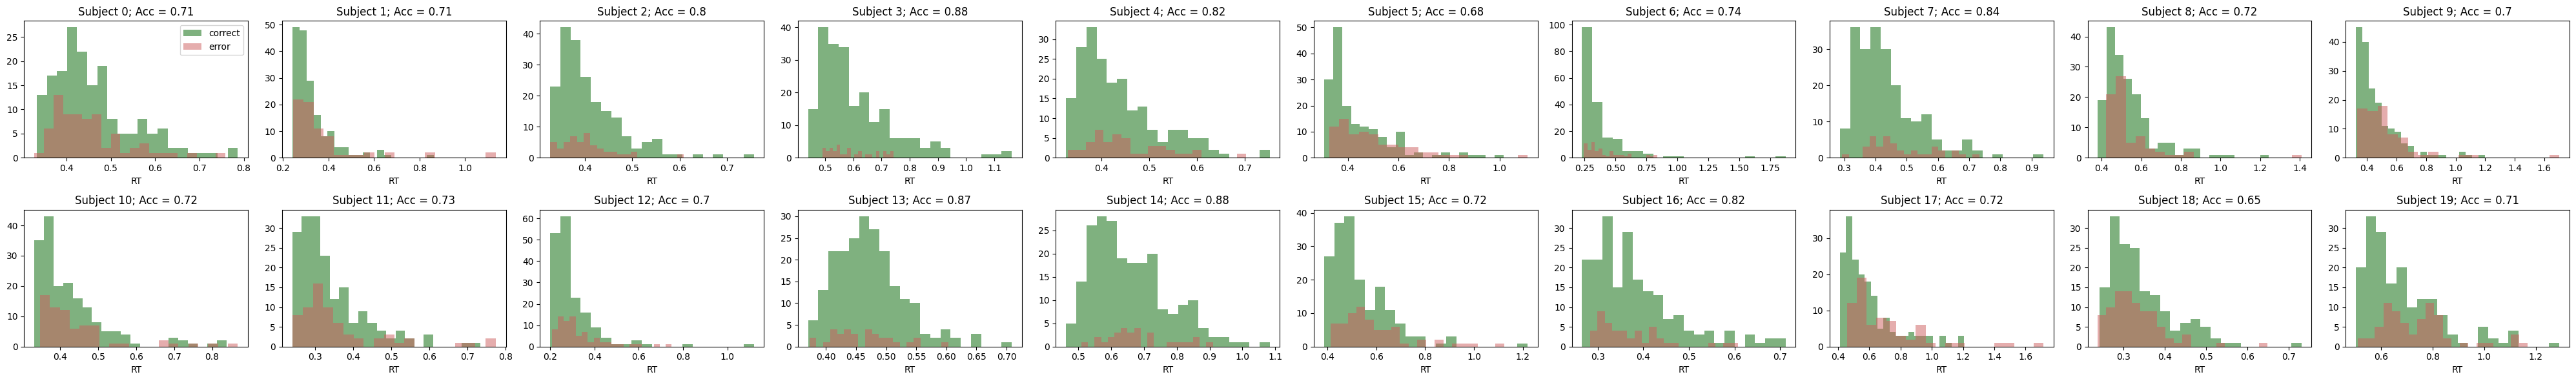

In [76]:
plot_data_hist(dt);